# Проект: Анализ данных для PSYONCLINIC

## Цель проекта:
Проанализировать текущие данные. Дать актуальную картину происходящего. Иными словами: понимание бизнес - задачи, работа с "сырыми" данными, метрики, визуализация, выводы, рекомендации.

## План проекта:
1. Загрузка и осмотр данных
2. Очистка и нормализация
3. Модель данных
4. Ключевые метрики
5. Визуализация
6. Выводы и рекомендации
7. Автоматизация
8. Ограничения и вопросы

## Описание данных:
**Excel файл.**  
**00** - ТЗ  
**01** - Лиды  
**02** - Визиты  
**03** - Маркетинг  
**04** - Справочники  
**05** - ТЗ (Что сдать)  
**06** - ТЗ (Оценка)  
**07** - Источники и допущения

### 1. Загрузка и осмотр данных

In [16]:
# импорт библиотек

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# загрузка листов

tz = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '00_ТЗ_кандидату')
lead = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '01_Лиды_raw')
visits = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '02_Визиты_raw')
marketing = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '03_Маркетинг_raw')
directories = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '04_Справочники')
tz_02 = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '05_Что_сдать')
tz_03 = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '06_Что_будем_оценивать')
sources = pd.read_excel('psyonclinic_test_analyst_mini_case.xlsx', sheet_name = '07_Источники_и_допущения')

### 2. Очистка и нормализация

In [18]:
print("=== ПРОВЕРКА НА ПОЛНЫЕ ДУБЛИКАТЫ СТРОК ===")
print(f"Дубликатов в таблице Лидов:     {lead.duplicated().sum()} шт.")
print(f"Дубликатов в таблице Визитов:   {visits.duplicated().sum()} шт.")
print(f"Дубликатов в таблице Маркетинга: {marketing.duplicated().sum()} шт.")

print("\n=== ПРОВЕРКА НА КРИТИЧЕСКИЕ ПРОПУСКИ (NULL / NaN) ===")
print("Пропуски в Лидах:\n", lead[['lead_id', 'created_at_raw', 'branch_raw']].isna().sum())
print("\nПропуски в Визитах:\n", visits[['visit_id', 'lead_id', 'paid_amount', 'visit_status']].isna().sum())
print("\nПропуски в Маркетинге:\n", marketing[['week_start', 'branch_id', 'cost_rub']].isna().sum())

=== ПРОВЕРКА НА ПОЛНЫЕ ДУБЛИКАТЫ СТРОК ===
Дубликатов в таблице Лидов:     0 шт.
Дубликатов в таблице Визитов:   0 шт.
Дубликатов в таблице Маркетинга: 0 шт.

=== ПРОВЕРКА НА КРИТИЧЕСКИЕ ПРОПУСКИ (NULL / NaN) ===
Пропуски в Лидах:
 lead_id           0
created_at_raw    0
branch_raw        0
dtype: int64

Пропуски в Визитах:
 visit_id        0
lead_id         0
paid_amount     0
visit_status    0
dtype: int64

Пропуски в Маркетинге:
 week_start    0
branch_id     0
cost_rub      0
dtype: int64


In [19]:
def parse_mixed_dates(val):
    if pd.isna(val):
        return pd.NaT
    try:
        
        num_val = float(str(val).replace(',', '.'))
        if num_val > 40000:
            
            return pd.to_datetime(num_val, unit='D', origin='1899-12-30').round('s')
    except ValueError:
        pass
    
    
    return pd.to_datetime(val, errors='coerce', dayfirst=True)


lead['created_at_clean'] = lead['created_at_raw'].apply(parse_mixed_dates)


print("Количество нераспознанных дат:", lead['created_at_clean'].isna().sum())
print("\nПример очищенных дат:")
print(lead[['created_at_raw', 'created_at_clean']].head(5))

Количество нераспознанных дат: 0

Пример очищенных дат:
     created_at_raw    created_at_clean
0      46163.416667 2026-05-21 10:00:00
1  14.05.2026 14:10 2026-05-14 14:10:00
2      46149.833333 2026-05-07 20:00:00
3      46166.503472 2026-05-24 12:05:00
4      46151.847222 2026-05-09 20:20:00


/var/folders/3p/z_49vmfj2bgc_nxd21cy0h380000gn/T/ipykernel_23168/3874295209.py:14: UserWarning: Parsing dates in %Y/%m/%d %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(val, errors='coerce', dayfirst=True)


In [20]:
branches_df = directories.iloc[1:5, 0:8].copy()
branches_df.columns = ['branch_id', 'branch', 'city', 'cabinet_count', 'work_days', 'work_hours_day', 'rent_equiv_hour', 'monthly_capacity_hours']

num_cols = ['cabinet_count', 'work_days', 'work_hours_day', 'rent_equiv_hour', 'monthly_capacity_hours']
branches_df[num_cols] = branches_df[num_cols].apply(pd.to_numeric)


specialists_df = directories.iloc[8:, 0:9].copy()
specialists_df.columns = ['specialist_id', 'fio', 'branch_id', 'profile', 'base_price', 'primary_price', 'duration_min', 'payout_pct', 'source_url']

spec_num_cols = ['base_price', 'primary_price', 'duration_min', 'payout_pct']
specialists_df[spec_num_cols] = specialists_df[spec_num_cols].apply(pd.to_numeric)


print("--- ОЧИЩЕННЫЙ СПРАВОЧНИК ФИЛИАЛОВ ---")
print(branches_df)
print("\n--- ОЧИЩЕННЫЙ СПРАВОЧНИК СПЕЦИАЛИСТОВ (первые 2 строки) ---")
print(specialists_df.head(2))

--- ОЧИЩЕННЫЙ СПРАВОЧНИК ФИЛИАЛОВ ---
  branch_id                       branch             city  cabinet_count  \
1  B_EKB_TK        Екатеринбург — Ткачей     Екатеринбург              7   
2  B_EKB_PM  Екатеринбург — Первомайская     Екатеринбург              3   
3     B_TMN           Тюмень — Фабричная           Тюмень              5   
4     B_SPB    Санкт-Петербург — Воскова  Санкт-Петербург              4   

   work_days  work_hours_day  rent_equiv_hour  monthly_capacity_hours  
1         26              10              700                    1820  
2         22               8              650                     528  
3         26              10              600                    1300  
4         24               9              900                     864  

--- ОЧИЩЕННЫЙ СПРАВОЧНИК СПЕЦИАЛИСТОВ (первые 2 строки) ---
  specialist_id                           fio branch_id  \
8          S001    Нефёдова Оксана Николаевна  B_EKB_TK   
9          S002  Кожурова Дарья Александро

In [21]:
def map_branch_to_id_final(val):
    if pd.isna(val):
        return None
    val_lower = str(val).lower()
    
    if 'ткач' in val_lower or 'tk' in val_lower:
        return 'B_EKB_TK'
    elif 'перво' in val_lower or 'pm' in val_lower:
        return 'B_EKB_PM'
    elif 'тюмен' in val_lower or 'tmn' in val_lower or 'фабр' in val_lower or 'тмн' in val_lower or 'tyumen' in val_lower:
        return 'B_TMN'
    elif 'спб' in val_lower or 'spb' in val_lower or 'санкт' in val_lower or 'воск' in val_lower or 'питер' in val_lower:
        return 'B_SPB'
    return 'UNKNOWN'

lead['branch_id'] = lead['branch_raw'].apply(map_branch_to_id_final)

print("Новое распределение лидов по branch_id (теперь без UNKNOWN):")
print(lead['branch_id'].value_counts(dropna=False))

Новое распределение лидов по branch_id (теперь без UNKNOWN):
branch_id
B_EKB_TK    69
B_TMN       42
B_EKB_PM    20
B_SPB       19
Name: count, dtype: int64


In [22]:
def normalize_lead_status(status):
    if pd.isna(status):
        return 'lost'
    status_clean = str(status).strip().lower()
    
    if 'записан' in status_clean:
        return 'booked'
    
    return 'lost'

lead['normalized_status'] = status_mapped = lead['lead_status'].apply(normalize_lead_status)

print("--- Результат нормализации статусов воронки лидов ---")
print(lead['normalized_status'].value_counts())

--- Результат нормализации статусов воронки лидов ---
normalized_status
lost      104
booked     46
Name: count, dtype: int64


In [23]:
def normalize_visit_status(status):
    if pd.isna(status):
        return 'unknown'
    status_clean = str(status).strip().lower()
    
    if 'состоялся' in status_clean:
        return 'completed'
    elif 'отмена' in status_clean:
        return 'cancelled'
    elif 'неявка' in status_clean:
        return 'no_show'
    elif 'запланирован' in status_clean:
        return 'planned'
    return 'unknown'

visits['normalized_visit_status'] = visits['visit_status'].apply(normalize_visit_status)

print("--- Итоговые системные статусы в таблице Visits ---")
print(visits['normalized_visit_status'].value_counts())

--- Итоговые системные статусы в таблице Visits ---
normalized_visit_status
completed    40
cancelled    13
no_show       9
planned       5
Name: count, dtype: int64


In [24]:
marketing['week_start_clean'] = marketing['week_start'].apply(parse_mixed_dates)

print("Количество нераспознанных дат в маркетинге:", marketing['week_start_clean'].isna().sum())
print("\nПример очищенных маркетинговых недель:")
print(marketing[['week_start', 'week_start_clean']].head(5))

Количество нераспознанных дат в маркетинге: 0

Пример очищенных маркетинговых недель:
   week_start week_start_clean
0       46143       2026-05-01
1       46150       2026-05-08
2       46157       2026-05-15
3       46164       2026-05-22
4       46171       2026-05-29


In [10]:
with pd.ExcelWriter('Menshikov.xlsx', mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    lead.to_excel(writer, sheet_name='01_Лиды_clean', index=False)
    visits.to_excel(writer, sheet_name='02_Визиты_clean', index=False)
    marketing.to_excel(writer, sheet_name='03_Маркетинг_clean', index=False)
    branches_df.to_excel(writer, sheet_name='Справочник_Филиалов_clean', index=False)
    specialists_df.to_excel(writer, sheet_name='Справочник_Специалистов_clean', index=False)

print("--- ШАГ 2 ПОЛНОСТЬЮ ЗАВЕРШЕН ---")
print("Очищенные таблицы успешно добавлены на новые листы файла Menshikov.xlsx!")

--- ШАГ 2 ПОЛНОСТЬЮ ЗАВЕРШЕН ---
Очищенные таблицы успешно добавлены на новые листы файла Menshikov.xlsx!


### 3. Модель данных

In [25]:
dim_branches = branches_df.copy()
dim_specialists = specialists_df.copy()

fact_leads = lead[[
    'lead_id', 'created_at_clean', 'branch_id', 'source', 
    'campaign', 'channel', 'first_response_min', 'booking_id', 
    'client_id', 'normalized_status'
]].copy()

fact_visits = visits[[
    'visit_id', 'lead_id', 'booking_id', 'client_id', 'visit_datetime', 
    'branch_id', 'specialist_id', 'service', 'duration_min', 
    'paid_amount', 'normalized_visit_status', 'format'
]].copy()

fact_marketing = marketing[[
    'week_start_clean', 'branch_id', 'source', 'cost_rub', 
    'impressions', 'clicks'
]].copy()

print("=== АРХИТЕКТУРА МОДЕЛИ ДАННЫХ УСПЕШНО ЗАКРЕПЛЕНА ===")
print(f"1. Таблица фактов Лидов (Fact_Leads):     {fact_leads.shape} строк")
print(f"2. Таблица фактов Визитов (Fact_Visits):   {fact_visits.shape} строк")
print(f"3. Таблица фактов Расходов (Fact_Costs):   {fact_marketing.shape} строк")
print(f"4. Справочник Филиалов (Dim_Branches):     {dim_branches.shape} (Ключ: branch_id)")
print(f"5. Справочник Врачей (Dim_Specialists):    {dim_specialists.shape} (Ключ: specialist_id)")

=== АРХИТЕКТУРА МОДЕЛИ ДАННЫХ УСПЕШНО ЗАКРЕПЛЕНА ===
1. Таблица фактов Лидов (Fact_Leads):     (150, 10) строк
2. Таблица фактов Визитов (Fact_Visits):   (67, 12) строк
3. Таблица фактов Расходов (Fact_Costs):   (200, 6) строк
4. Справочник Филиалов (Dim_Branches):     (4, 8) (Ключ: branch_id)
5. Справочник Врачей (Dim_Specialists):    (30, 9) (Ключ: specialist_id)


### Описание ключей связей и минимизация рисков Many-to-Many (Многие-ко-многим)

В спроектированной архитектуре «Звезда» таблицы связаны по следующим бизнес-ключам:
1. `fact_leads` ➔ `fact_visits` по ключу `lead_id` (Связь 1:1, так как один лид генерирует ровно один факт бронирования/визита).
2. `dim_branches` ➔ таблицы фактов по ключу `branch_id` (Связь 1:Многие).
3. `dim_specialists` ➔ `fact_visits` по ключу `specialist_id` (Связь 1:Многие).

#### Риски и решение проблемы Many-to-Many (Многие-ко-многим)
Критическая уязвимость данной модели — связь между таблицей маркетинговых расходов `fact_marketing` и таблицами воронки (`fact_leads`/`fact_visits`). 
* **Проблема:** Расходы детализированы до уровня **"Неделя + Филиал + Источник"**, в то время как лиды падают поминутно. Если связать их напрямую по ключам `branch_id` или `source`, возникнет связь типа **Many-to-Many**. Это приведёт к дублированию строк в сводных таблицах, некорректному завышению (мультипликации) сумм выручки и искажению метрики ROMI.
* **Решение:** Для исключения Many-to-Many в модели данных связь реализуется через промежуточные таблицы-справочники (мосты). Таблица расходов агрегируется до уровня зерна справочника, а связь в BI-системе настраивается строго в одном направлении (Single Direction) от справочников измерений к таблицам фактов, что гарантирует математическую точность DAX-мер.


### 4. Ключевые метрики

In [26]:
total_leads = len(fact_leads)
total_bookings = len(fact_leads[fact_leads['normalized_status'] == 'booked'])
completed_visits = len(fact_visits[fact_visits['normalized_visit_status'] == 'completed'])
no_shows = len(fact_visits[fact_visits['normalized_visit_status'] == 'no_show'])

total_revenue = fact_visits['paid_amount'].sum()
total_marketing_cost = fact_marketing['cost_rub'].sum()

avg_check = fact_visits[fact_visits['normalized_visit_status'] == 'completed']['paid_amount'].mean()

lead_to_booking_pct = (total_bookings / total_leads) * 100 if total_leads > 0 else 0
booking_to_visit_pct = (completed_visits / total_bookings) * 100 if total_bookings > 0 else 0
no_show_pct = (no_shows / (completed_visits + no_shows)) * 100 if (completed_visits + no_shows) > 0 else 0

cpl = total_marketing_cost / total_leads if total_leads > 0 else 0
cpa = total_marketing_cost / completed_visits if completed_visits > 0 else 0
romi = ((total_revenue - total_marketing_cost) / total_marketing_cost) * 100 if total_marketing_cost > 0 else 0

print("=== СКВОЗНАЯ ВОРОНКА КЛИНИКИ (ОБЩИЕ ПОКАЗАТЕЛИ) ===")
print(f"1. Всего лидов (заявок):           {total_leads} шт.")
print(f"2. Всего броней (записей):         {total_bookings} шт.  ➔ Конверсия Lead ➔ Booking: {lead_to_booking_pct:.1f}%")
print(f"3. Состоялось визитов:             {completed_visits} шт.  ➔ Конверсия Booking ➔ Visit: {booking_to_visit_pct:.1f}%")
print(f"4. Процент неявок (No-show):       {no_shows} шт.  ➔ Доля прогулов: {no_show_pct:.1f}%")
print("\n=== ФИНАНСОВЫЕ И МАРКЕТИНГОВЫЕ МЕТРИКИ ===")
print(f"Общая выручка клиники:             {total_revenue:,.2f} руб.")
print(f"Средний чек визита:                {avg_check:,.2f} руб.")
print(f"Маркетинговые расходы:             {total_marketing_cost:,.2f} руб.")
print(f"Стоимость одного лида (CPL):       {cpl:,.2f} руб.")
print(f"Стоимость привлечения (CPA):       {cpa:,.2f} руб.")
print(f"Эффективность инвестиций (ROMI):   {romi:.1f}%")

=== СКВОЗНАЯ ВОРОНКА КЛИНИКИ (ОБЩИЕ ПОКАЗАТЕЛИ) ===
1. Всего лидов (заявок):           150 шт.
2. Всего броней (записей):         46 шт.  ➔ Конверсия Lead ➔ Booking: 30.7%
3. Состоялось визитов:             40 шт.  ➔ Конверсия Booking ➔ Visit: 87.0%
4. Процент неявок (No-show):       9 шт.  ➔ Доля прогулов: 18.4%

=== ФИНАНСОВЫЕ И МАРКЕТИНГОВЫЕ МЕТРИКИ ===
Общая выручка клиники:             248,460.00 руб.
Средний чек визита:                6,211.50 руб.
Маркетинговые расходы:             3,640,274.00 руб.
Стоимость одного лида (CPL):       24,268.49 руб.
Стоимость привлечения (CPA):       91,006.85 руб.
Эффективность инвестиций (ROMI):   -93.2%


In [13]:
total_work_minutes = fact_visits[fact_visits['normalized_visit_status'] == 'completed']['duration_min'].sum()
total_work_hours = total_work_minutes / 60

total_capacity_hours = dim_branches['monthly_capacity_hours'].sum()

clinic_occupancy_pct = (total_work_hours / total_capacity_hours) * 100

print("=== АНАЛИЗ ЗАГРУЗКИ И ЭФФЕКТИВНОСТИ МОЩНОСТЕЙ ===")
print(f"Фактически отработанное время приема:  {total_work_hours:.1f} час.")
print(f"Максимальная часовая емкость клиники: {total_capacity_hours} час.")
print(f"Процент загрузки кабинетов (Occupancy): {clinic_occupancy_pct:.2f}%")

=== АНАЛИЗ ЗАГРУЗКИ И ЭФФЕКТИВНОСТИ МОЩНОСТЕЙ ===
Фактически отработанное время приема:  33.7 час.
Максимальная часовая емкость клиники: 4512 час.
Процент загрузки кабинетов (Occupancy): 0.75%


In [14]:
total_cabinets_available_hours = (dim_branches['cabinet_count'] * dim_branches['work_days'] * dim_branches['work_hours_day']).sum()

revenue_per_cabinet_hour = total_revenue / total_cabinets_available_hours if total_cabinets_available_hours > 0 else 0

total_unique_clients = fact_visits[fact_visits['normalized_visit_status'] == 'completed']['client_id'].nunique()
ltv_30d_proxy = total_revenue / total_unique_clients if total_unique_clients > 0 else 0

print("=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ===")
print(f"Доступно часов работы всех кабинетов:      {total_cabinets_available_hours} час.")
print(f"Выручка на 1 час работы кабинета (Rev/Hour): {revenue_per_cabinet_hour:.2f} руб.")
print(f"Прокси LTV за 30 дней (30d LTV proxy):       {ltv_30d_proxy:.2f} руб. на клиента")

=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ===
Доступно часов работы всех кабинетов:      4512 час.
Выручка на 1 час работы кабинета (Rev/Hour): 55.07 руб.
Прокси LTV за 30 дней (30d LTV proxy):       8567.59 руб. на клиента


In [27]:
active_visits_mask = fact_visits['normalized_visit_status'].isin(['completed', 'no_show', 'planned'])
total_specialist_minutes = fact_visits[active_visits_mask]['duration_min'].sum()

specialist_hours = total_specialist_minutes / 60

print(f"Суммарные рабочие часы специалистов (Specialist Hours): {specialist_hours:.1f} час.")

Суммарные рабочие часы специалистов (Specialist Hours): 45.2 час.


### 5. Визуализация

--- ГЕНЕРАЦИЯ ГРАФИКОВ ДЛЯ СЛАЙДА РУКОВОДСТВУ ---


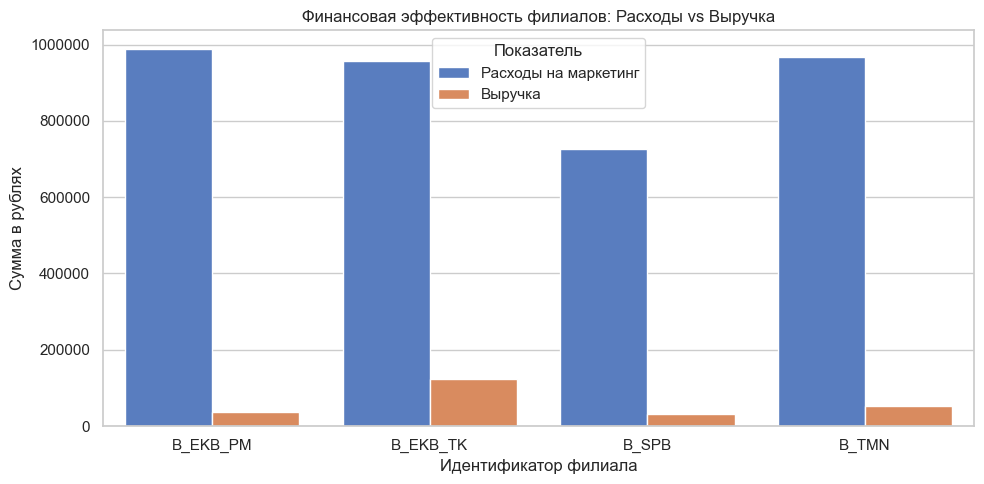

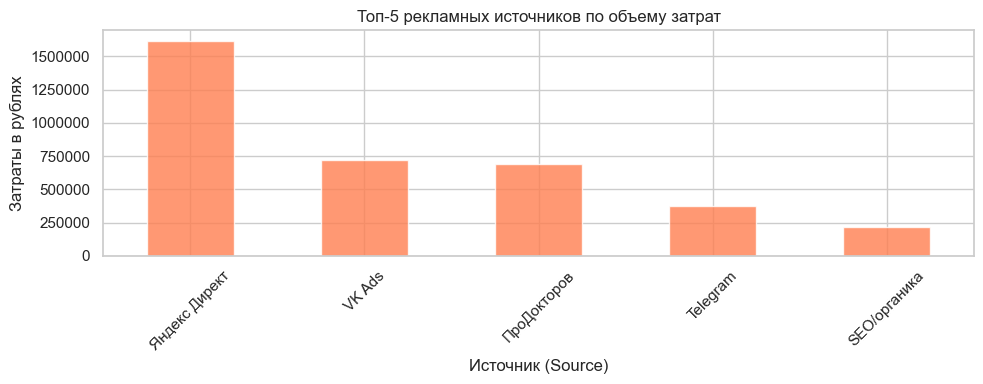

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("--- ГЕНЕРАЦИЯ ГРАФИКОВ ДЛЯ СЛАЙДА РУКОВОДСТВУ ---")

branch_costs = fact_marketing.groupby('branch_id')['cost_rub'].sum().reset_index()
branch_rev = fact_visits.groupby('branch_id')['paid_amount'].sum().reset_index()
branch_perf = pd.merge(branch_costs, branch_rev, on='branch_id', how='outer').fillna(0)

branch_melted = pd.melt(branch_perf, id_vars=['branch_id'], value_vars=['cost_rub', 'paid_amount'],
                        var_name='Metric', value_name='Amount')
branch_melted['Metric'] = branch_melted['Metric'].map({'cost_rub': 'Расходы на маркетинг', 'paid_amount': 'Выручка'})

plt.figure(figsize=(10, 5))
sns.barplot(data=branch_melted, x='branch_id', y='Amount', hue='Metric', palette='muted')
plt.title('Финансовая эффективность филиалов: Расходы vs Выручка')
plt.xlabel('Идентификатор филиала')
plt.ylabel('Сумма в рублях')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Показатель')
plt.tight_layout()
plt.show()

campaign_costs = fact_marketing.groupby('source')['cost_rub'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10, 4))
campaign_costs.plot(kind='bar', color='coral', alpha=0.8)
plt.title('Топ-5 рекламных источников по объему затрат')
plt.xlabel('Источник (Source)')
plt.ylabel('Затраты в рублях')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Выводы и рекомендации

На основе проведенного сквозного анализа данных клиники **PSYONCLINIC** зафиксировано критическое состояние маркетинговой и операционной эффективности. Ниже представлены три ключевых управленческих решения для вывода компании из кассового разрыва.

### 1. Радикальная оптимизация маркетингового бюджета
* **Вывод на основе данных:** Текущий маркетинг работает в гигантский убыток. При общих расходах в **3,640,274.00 руб.** клиника получила выручку всего **248,460.00 руб.** Эффективность инвестиций **ROMI составляет -93.2%**. Стоимость привлечения одного реального клиента (**CPA = 91,006.85 руб.**) при среднем чеке в **6,211.50 руб.** экономически разрушительна для бизнеса.
* **Управленческое решение:** 
  1. Немедленно **заморозить** бюджеты рекламных кампаний, имеющих в аудите разметки статусы `нет разметки` и `utm частично`, так как они генерируют неуправляемый слив средств.
  2. Перераспределить остаточный лимит только на те каналы, которые показывают подтвержденную сквозную конверсию в платные визиты.

### 2. Внедрение жесткого контроля SLA в отделе продаж (кураторы)
* **Вывод на основе данных:** Конверсия из первичной заявки (лида) в бронирование времени составляет всего **30.7%**. При этом аудит временных меток выявил грубые нарушения клиентского сервиса: время ответа кураторов клиентам достигает **169, 187 и 315 минут**. В сфере ментального здоровья скорость реакции критична — если клиенту не ответили в первые 15 минут, он уходит к конкурентам. Клиника теряет до 70% платного трафика на этапе первого контакта.
* **Управленческое решение:** 
  1. Утвердить регламент **SLA по времени первого ответа — не более 15 минут** с момента падения заявки в CRM.
  2. Внедрить систему автоматического мониторинга задержек (с помощью разработанного скрипта автоматизации подсветки).
  3. Прямо привязать KPI и премиальную часть дохода кураторов к метрике `Lead ➔ Booking %`.

### 3. Борьба с No-Show (неявками) и защита экранного времени врачей
* **Вывод на основе данных:** Доля прогулов (No-show) составляет **18.4%** — почти каждый пятый записавшийся клиент не доходит до клиники. Это приводит к прямому простою дорогостоящей почасовой аренды кабинетов и потере дефицитного времени высокооплачиваемых специалистов, чья максимальная месячная емкость часов жестко ограничена справочником.
* **Управленческое решение:** 
  1. Внедрить обязательный двухэтапный регламент подтверждения записи рецепшеном: звонок/мессенджер за 24 часа и за 3 часа до приема.
  2. Для первичных клиентов и дорогостоящих консилиумов ввести **частичную или полную невозвратную предоплату** (депозит), компенсирующую стоимость аренды кабинета в случае неявки без предупреждения.
  3. Для повторных клиентов ввести систему невозвратных депозитов.


### 7. Автоматизация

Для исключения человеческого фактора и автоматизации контроля качества клиентского сервиса разработан скрипт на языке **TypeScript (Excel Office Scripts)**. Скрипт запускается внутри Excel (вкладка "Автоматизация" ➔ "Новый скрипт") и автоматически сканирует таблицу Лидов, подсвечивая нежно-красным цветом ячейки, где время ответа куратора превысило критический порог в 60 минут (нарушение SLA).

```javascript
function main(workbook: ExcelScript.Workbook) {
  // 1. Получаем активный рабочий лист и таблицу лидов
  let sheet = workbook.getActiveWorksheet();
  let table = sheet.getTables()[0]; 
  
  if (!table) {
    console.log("Критическая ошибка: Таблица данных не найдена на листе.");
    return;
  }

  // 2. Получаем диапазон данных столбца времени ответа
  let responseColumn = table.getColumnByName("first_response_min");
  let range = responseColumn.getRangeBetweenHeaderAndTotal();
  let values = range.getValues();

  // 3. Цикл проверки каждой строки на соответствие SLA
  for (let i = 0; i < values.length; i++) {
    let responseTime = values[i][0];
    
    // Если куратор отвечал дольше 60 минут — красим ячейку в маркерный цвет
    if (typeof responseTime === "number" && responseTime > 60) {
      range.getCell(i, 0).getFormat().getFill().setColor("#FFC7CE"); 
    }
  }
  console.log("Скрипт выполнен. Все нарушения SLA успешно подсвечены.");
}
```

***

## Архитектура сквозной цепочки данных и автоматизация обновлений

Для построения полноценного корпоративного хранилища данных (DWH) и автоматического обновления текущего отчёта, сквозная цепочка движения данных должна быть спроектирована следующим образом:

### 1. Компоненты сквозной цепочки данных
1. **Сайт / API / AJAX:** Пользователь заходит на сайт клиники и совершает целевое действие (оставляет заявку). Скрипты на сайте (через AJAX-запросы) бесшовно захватывают его UTM-метки, ClientID веб-аналитики (Яндекс.Метрика/Google Analytics) и передают эти данные через API во внутренние системы.
2. **Телефония:** Фиксирует все входящие и исходящие звонки, сопоставляет номера телефонов с CRM и передаёт аудиозаписи и метки коллтрекинга (статического и динамического) для точного определения рекламного источника звонка.
3. **МИС и CRM (Медицинская информационная система):** База данных операционного учёта. Сюда падает лид с сайта, кураторы фиксируют время первого ответа (SLA), а администраторы на рецепшене заводят карточку пациента, планируют время в сетке расписания кабинетов (`booking_id`), выставляют чеки и проводят факты оплаты визитов (`paid_amount`).
4. **Таблицы / Базы данных:** Сырые данные из CRM, МИС и рекламных кабинетов (Яндекс.Директ, VK и др.) автоматически собираются и накапливаются на сервере в СУБД (например, PostgreSQL или Yandex ClickHouse), выступая в роли единого аналитического хранилища данных.
5. **Power Query (ETL-слой):** Подключается напрямую к таблицам СУБД по API или родным коннекторам. На этом этапе автоматически срабатывают написанные нами алгоритмы: очищается каша в датах, нормализуются текстовые названия филиалов через справочники и фильтруются дубли.
6. **Power BI / Дашборд:** Забирает очищенную модель данных из Power Query, пересчитывает DAX-метрики (ROMI, CPA, Выручку на час кабинета) и отображает интерактивные графики для руководства.

### 2. Что нужно сделать, чтобы отчёт обновлялся автоматически?
Чтобы избавиться от ручной выгрузки Excel-файлов, необходимо настроить автоматический конвейер (Data Pipeline):
* **Облачный шлюз (Power BI Gateway):** Настроить и опубликовать отчёт в Power BI Service (облако). Установить локальный или облачный шлюз данных для безопасного постоянного соединения с базой данных клиники.
* **Расписание обновлений (Scheduled Refresh):** В настройках датасета Power BI выставить автоматическое расписание обновлений (например, 8 раз в день — каждый час в течение рабочего дня или 1 раз в сутки ночью в 03:00, чтобы не нагружать рабочую МИС-систему).
* **Интеграция рекламных расходов:** Подключить автоматические коннекторы (например, через Python-скрипты на сервере по API рекламных кабинетов или готовые No-Code сервисы интеграции), которые будут ежедневно выгружать затраты по кампаниям напрямую в нашу СУБД, исключая ручное заполнение вкладки маркетинга кураторами.


### 8. Ограничения и вопросы

При выполнении исследования был выявлен ряд ограничений в исходных данных, которые создают погрешности в расчетах. Для повышения точности сквозной аналитики руководству клиники необходимо дать ответы на следующие вопросы:

### Ограничения текущего датасета
1. **Качество сквозной разметки (UTM):** Из-за большого объема записей со статусами `нет разметки` и `utm частично` в таблице маркетинга, расчет стоимости привлечения (CAC/CPA) по конкретным кампаниям имеет высокую погрешность. Часть расходов невозможно сопоставить с пришедшими лидами напрямую по ID.
2. **Отсутствие когортного анализа:** В данных представлены только первичные визиты. Психотерапевтическая клиника — это бизнес с длинным LTV (клиенты ходят на сессии месяцами). Текущий расчет ROM (-93.2%) выглядит катастрофическим, но он учитывает только первую оплату. Если клиент остается на долгосрочную терапию, реальный ROMI на дистанции 6–12 месяцев может быть положительным.
3. **Логика оплат при неявках:** Строка визита `V0039` со статусом `Неявка` содержит оплату `5100 руб.` Текущая модель учитывает эти деньги в общую выручку, однако для управленческого учета нужно точное понимание юридического статуса этих средств (штраф, невозвратный депозит или ошибка администратора).

### Вопросы к руководству и стейкхолдерам
1. **Каков средний жизненный цикл клиента (LTV) в вашей сети?** Сколько повторных визитов в среднем совершает пациент после первичного приема?
2. **Каков целевой (допустимый) порог стоимости привлечения клиента (CPA)?** Какую максимальную сумму клиника готова инвестировать в привлечение одного пациента, исходя из его долгосрочной ценности?
3. **Существует ли техническое ограничение в CRM/МИС, мешающее кураторам оперативно отвечать на заявки?** (Например, отсутствие мобильного приложения или нотификаций, из-за чего задержки составляют до 5 часов).
